In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error

In [2]:
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
print("Shape :",df.shape)
print("\nData Types : \n",df.dtypes)
print("\nMissing Values : \n",df.isnull().sum())

Shape : (200, 5)

Data Types : 
 Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object

Missing Values : 
 Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [4]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


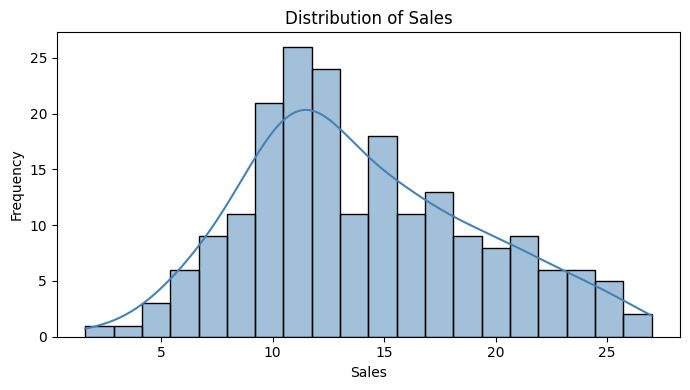

In [5]:
plt.figure(figsize=(7, 4))
sns.histplot(df['Sales'], kde=True, color='steelblue', bins=20)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

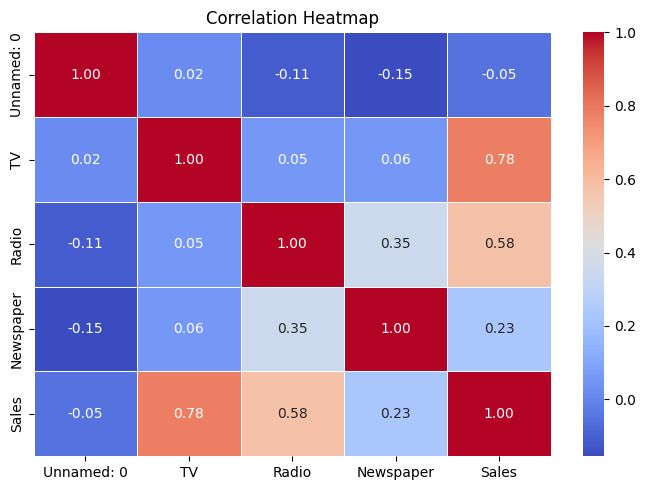

In [6]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

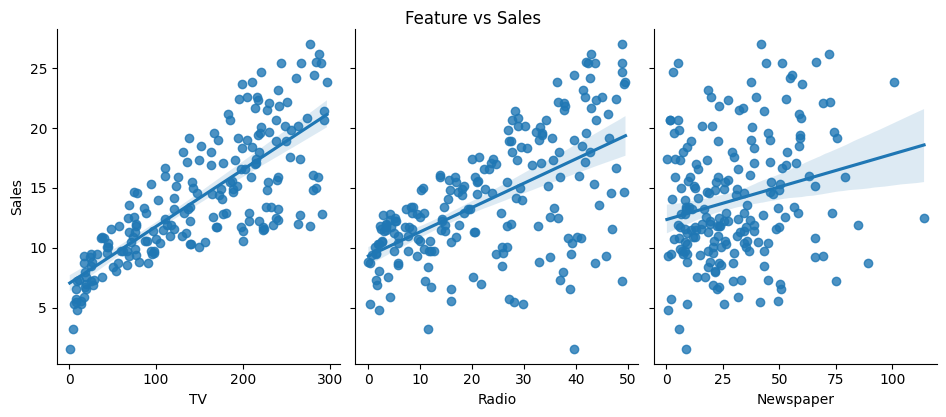

In [7]:
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales',
             height=4, aspect=0.8, kind='reg')
plt.suptitle("Feature vs Sales", y=1.02)
plt.show()

In [8]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200, 3)
Target shape: (200,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 160
Test size: 40


In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

Intercept: 2.979067338122629
Coefficients:
  TV: 0.0447
  Radio: 0.1892
  Newspaper: 0.0028


In [11]:
y_pred = model.predict(X_test)

# Preview first 10 predictions vs actual
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
comparison.head(10)

,Actual,Predicted
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


In [12]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"Mean Absolute Error  (MAE) : {mae:.4f}")
print(f"Mean Squared Error   (MSE) : {mse:.4f}")
print(f"Root Mean Sq Error  (RMSE) : {rmse:.4f}")
print(f"R² Score                   : {r2:.4f}")

Mean Absolute Error  (MAE) : 1.4608
Mean Squared Error   (MSE) : 3.1741
Root Mean Sq Error  (RMSE) : 1.7816
R² Score                   : 0.8994


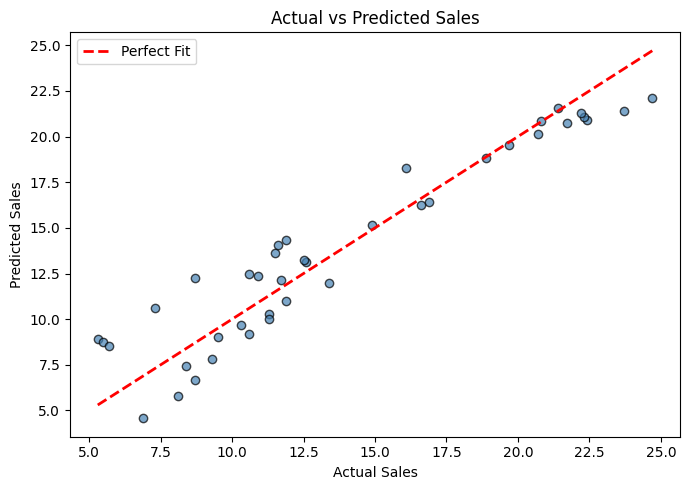

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='steelblue', edgecolors='k', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()

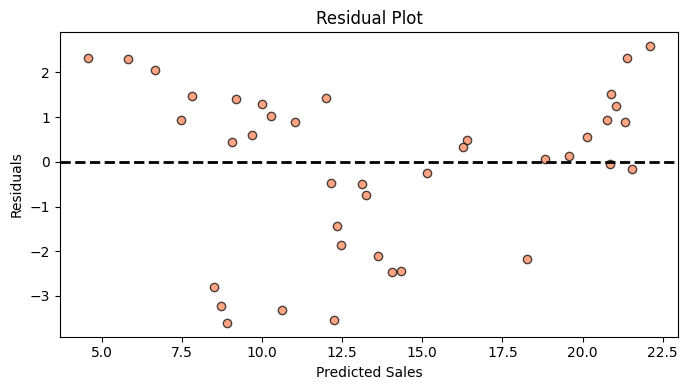

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, color='coral', edgecolors='k', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

In [15]:
# Example: TV=230, Radio=37, Newspaper=69
custom_input = pd.DataFrame({'TV': [230], 'Radio': [37], 'Newspaper': [69]})
predicted_sales = model.predict(custom_input)
print(f"Predicted Sales: {predicted_sales[0]:.2f} (in thousands)")

Predicted Sales: 20.46 (in thousands)
